# Fermont Bridge Bicycle Counter Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
fermont = pd.read_csv("Fremont_Bridge_Bicycle_Counter_20240404.csv" , index_col = "Date")
#URL of the csv file: https://data.seattle.gov/Transportation/Fremont-Bridge-Bicycle-Counter/65db-xm6k/about_data

In [2]:
fermont.head()

,"Fremont Bridge Sidewalks, south of N 34th St","Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk","Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk"
Date,,,
10/02/2012 01:00:00 PM,55.0,7.0,48.0
10/02/2012 02:00:00 PM,130.0,55.0,75.0
10/02/2012 03:00:00 PM,152.0,81.0,71.0
10/02/2012 04:00:00 PM,278.0,167.0,111.0
10/02/2012 05:00:00 PM,563.0,393.0,170.0


(array([-20000.,      0.,  20000.,  40000.,  60000.,  80000., 100000.,
        120000.]),
 [Text(-20000.0, 0, '12/19/2021 04:00:00 PM'),
  Text(0.0, 0, '10/02/2012 01:00:00 PM'),
  Text(20000.0, 0, '01/13/2015 09:00:00 PM'),
  Text(40000.0, 0, '04/26/2017 05:00:00 AM'),
  Text(60000.0, 0, '08/07/2019 01:00:00 PM'),
  Text(80000.0, 0, '11/17/2021 09:00:00 PM'),
  Text(100000.0, 0, '02/29/2024 05:00:00 AM'),
  Text(120000.0, 0, '')])

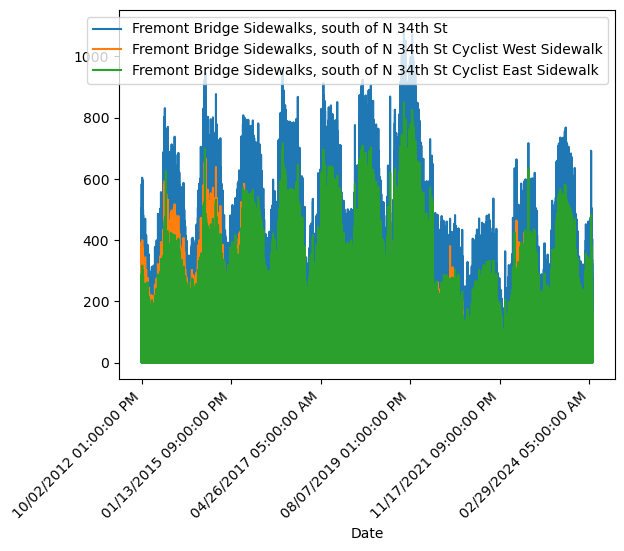

In [3]:
fermont.plot()
plt.xticks(rotation=45, ha='right')

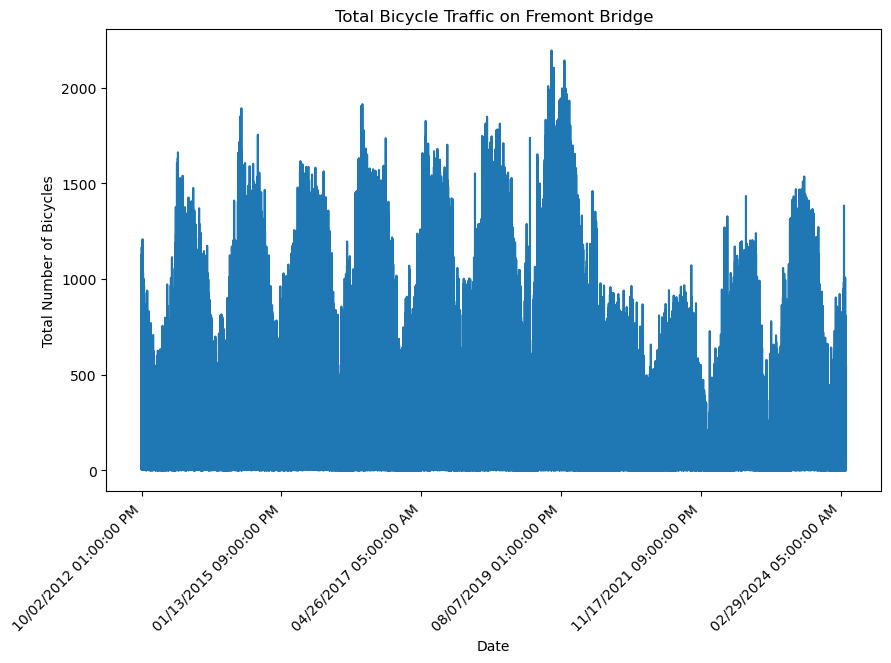

In [4]:
# Visualize the total bicycle traffic on the Fremont Bridge over time using a line plot

fermont = pd.read_csv("Fremont_Bridge_Bicycle_Counter_20240404.csv", index_col="Date")

total_bicycles = fermont.sum(axis=1)

total_bicycles.plot(figsize=(10, 6), title="Total Bicycle Traffic on Fremont Bridge")

plt.xlabel("Date")
plt.ylabel("Total Number of Bicycles")
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
fermont.columns.values

array(['Fremont Bridge Sidewalks, south of N 34th St',
       'Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk',
       'Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk'],
      dtype=object)

In [6]:
fermont.index = pd.to_datetime(fermont.index, format='%m/%d/%Y %I:%M:%S %p')

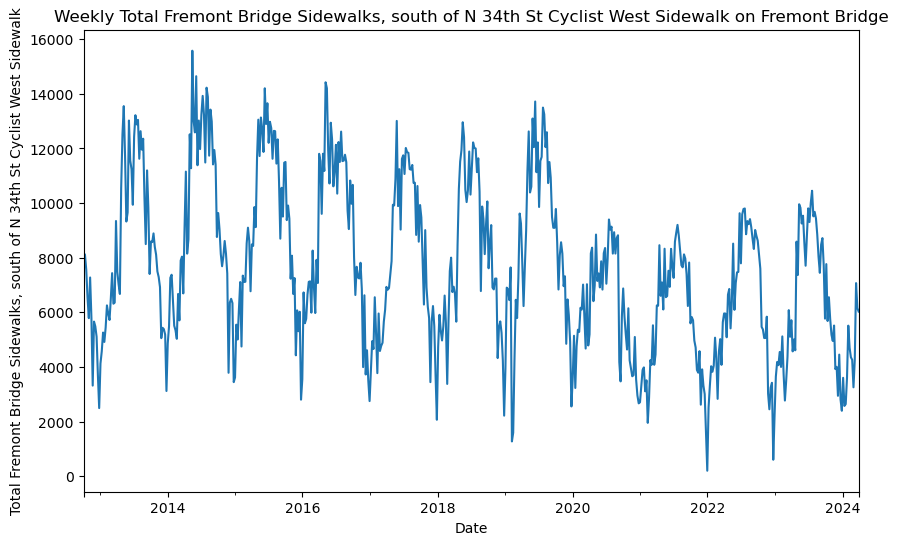

In [7]:
# Resample the data to weekly intervals and visualize the total bicycle traffic on the Fremont Bridge sidewalk over time using a line plot

column_to_plot = 'Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk'

weekly_sum = fermont[column_to_plot].resample('W').sum()
weekly_sum.plot(figsize=(10, 6), title=f"Weekly Total {column_to_plot} on Fremont Bridge")

plt.xlabel("Date")
plt.ylabel(f"Total {column_to_plot}")
plt.show()

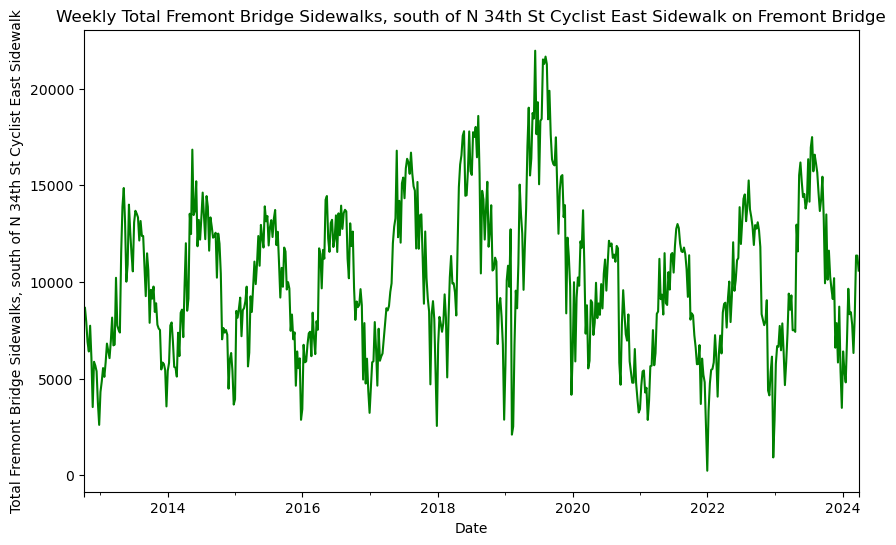

In [8]:
# Resample the data to weekly intervals and visualize the total bicycle traffic on the east sidewalk of the Fremont Bridge over time using a line plot.

column_to_plot = 'Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk'

weekly_sum = fermont[column_to_plot].resample('W').sum()

weekly_sum.plot(figsize=(10, 6), title=f"Weekly Total {column_to_plot} on Fremont Bridge", color='green')

plt.xlabel("Date")
plt.ylabel(f"Total {column_to_plot}")
plt.show()


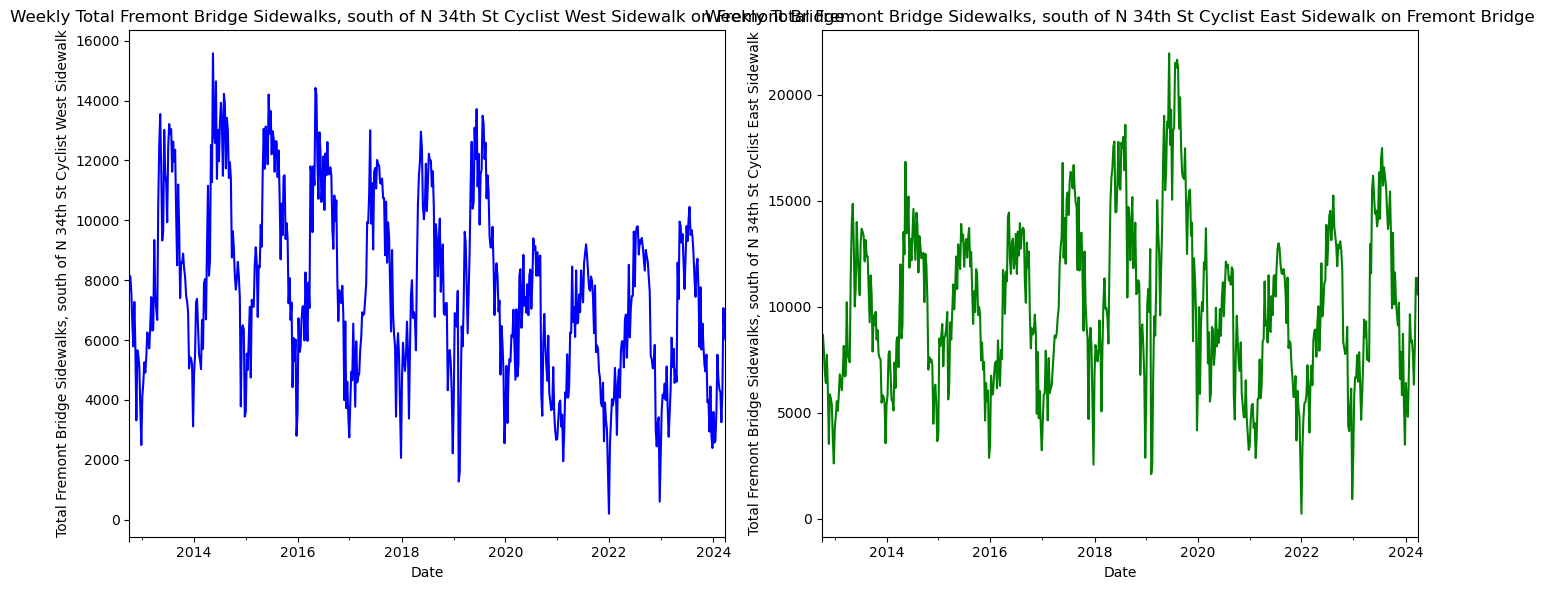

In [9]:
# Visualize the weekly total bicycle traffic on the west and east sidewalks of the Fremont Bridge separately in subplots

column_west = 'Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk'
column_east = 'Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk'

weekly_sum_west = fermont[column_west].resample('W').sum()
weekly_sum_east = fermont[column_east].resample('W').sum()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
weekly_sum_west.plot(title=f"Weekly Total {column_west} on Fremont Bridge", color='blue')
plt.xlabel("Date")
plt.ylabel(f"Total {column_west}")

plt.subplot(1, 2, 2)
weekly_sum_east.plot(title=f"Weekly Total {column_east} on Fremont Bridge", color='green')
plt.xlabel("Date")
plt.ylabel(f"Total {column_east}")
plt.tight_layout()
plt.show()


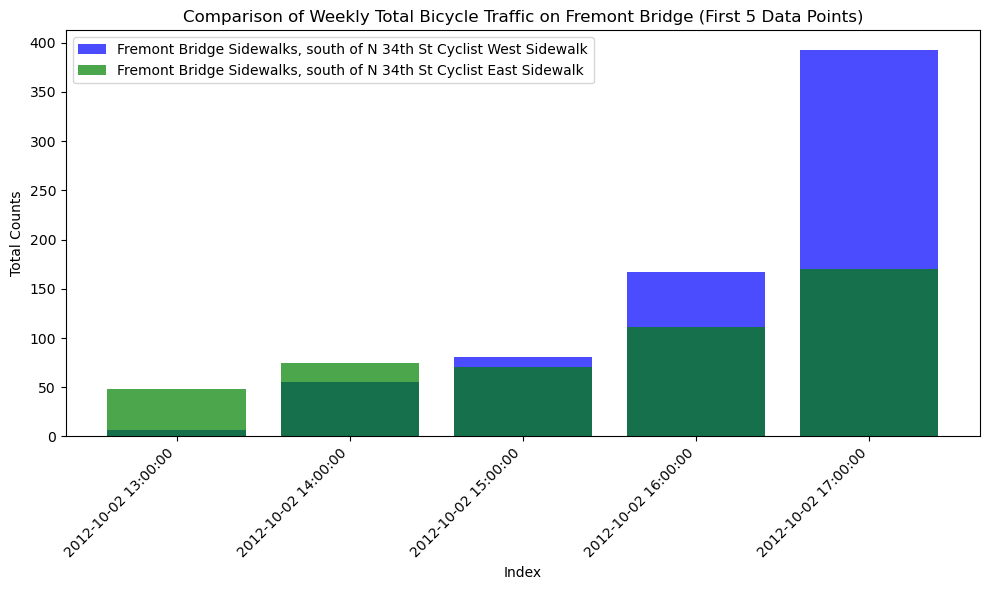

In [10]:
# Plot the first five data points from two columns of the Fermont DataFrame.

fermont_first_5 = fermont.head(5)
weekly_sum_west_first_5 = fermont_first_5[column_west]
weekly_sum_east_first_5 = fermont_first_5[column_east]

plt.figure(figsize=(10, 6))

plt.bar(range(len(weekly_sum_west_first_5)), weekly_sum_west_first_5, color='blue', alpha=0.7, label=column_west)
plt.bar(range(len(weekly_sum_east_first_5)), weekly_sum_east_first_5, color='green', alpha=0.7, label=column_east)

plt.xlabel("Index")
plt.ylabel("Total Counts")
plt.title("Comparison of Weekly Total Bicycle Traffic on Fremont Bridge (First 5 Data Points)")
plt.xticks(range(len(weekly_sum_west_first_5)), fermont_first_5.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

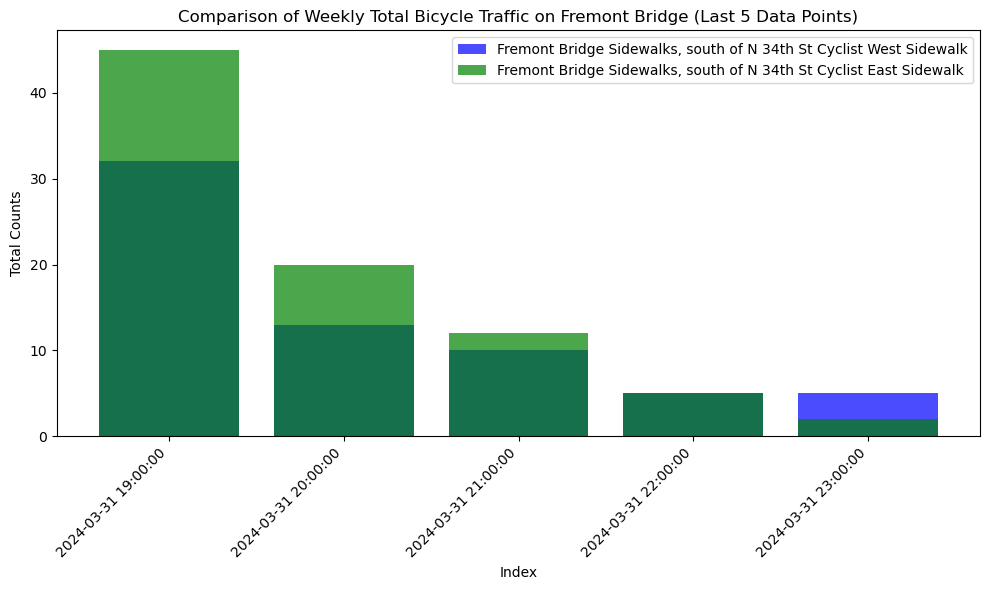

In [11]:
# Plot the last five data points from two columns of the Fermont DataFrame.

fermont_last_5 = fermont.tail(5)
weekly_sum_west_last_5 = fermont_last_5[column_west]
weekly_sum_east_last_5 = fermont_last_5[column_east]

plt.figure(figsize=(10, 6))

plt.bar(range(len(weekly_sum_west_last_5)), weekly_sum_west_last_5, color='blue', alpha=0.7, label=column_west)
plt.bar(range(len(weekly_sum_east_last_5)), weekly_sum_east_last_5, color='green', alpha=0.7, label=column_east)

plt.xlabel("Index")
plt.ylabel("Total Counts")
plt.title("Comparison of Weekly Total Bicycle Traffic on Fremont Bridge (Last 5 Data Points)")
plt.xticks(range(len(weekly_sum_west_last_5)), fermont_last_5.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

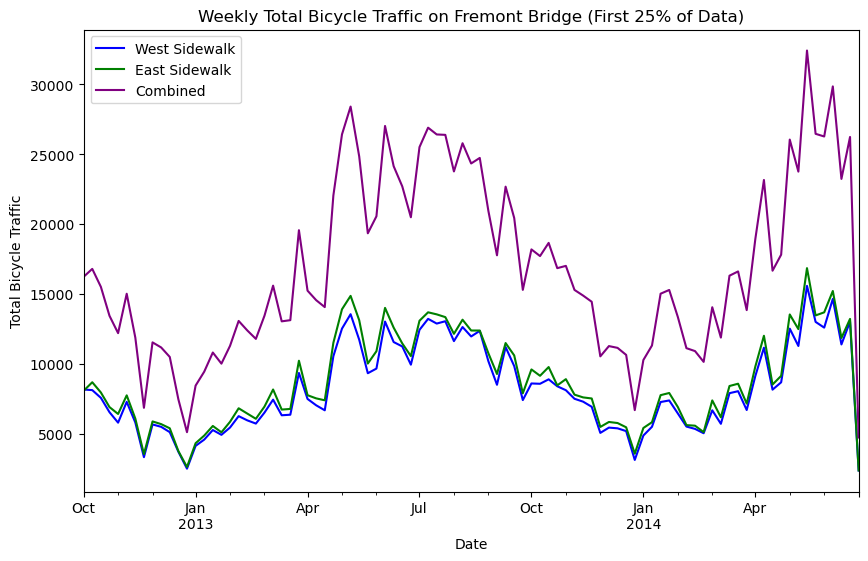

In [12]:
# Plot the weekly total bicycle traffic on the west and east and combined traffic, using data from the first 15% of observations

num_rows_to_show = int(len(fermont) * 0.15)

fermont_25 = fermont.head(num_rows_to_show)

column_west = 'Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk'
column_east = 'Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk'

weekly_sum_west = fermont_25[column_west].resample('W').sum()
weekly_sum_east = fermont_25[column_east].resample('W').sum()

# Combine the two datasets by summing them
weekly_sum_combined = weekly_sum_west + weekly_sum_east

plt.figure(figsize=(10, 6))


weekly_sum_west.plot(label='West Sidewalk', color='blue')
weekly_sum_east.plot(label='East Sidewalk', color='green')
weekly_sum_combined.plot(label='Combined', color='purple')

plt.xlabel("Date")
plt.ylabel("Total Bicycle Traffic")
plt.title("Weekly Total Bicycle Traffic on Fremont Bridge (First 25% of Data)")
plt.legend()
plt.show()

<Axes: xlabel='time'>

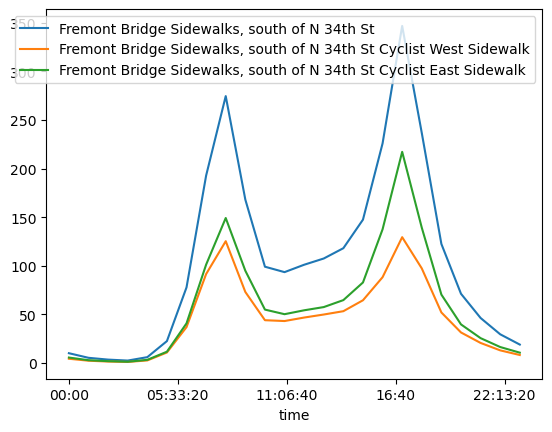

In [13]:
fermont.groupby(fermont.index.time).mean().plot()
# Plot the average bicycle traffic on the Fremont Bridge grouped by time of day

<Axes: xlabel='Date'>

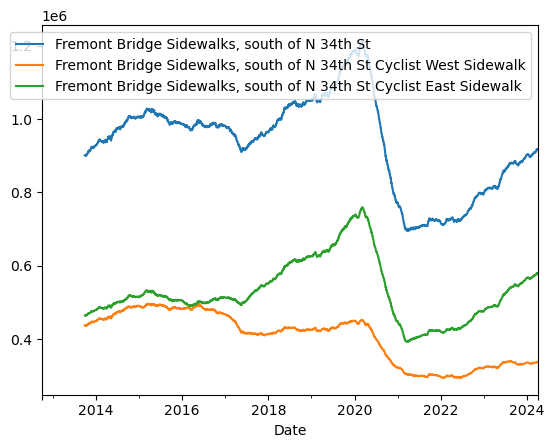

In [14]:
fermont.resample('D').sum().rolling(365).sum().plot()
# Plot the rolling sum of daily bicycle traffic on the Fremont Bridge, aggregated over a yearly period

In [15]:
pivoted = fermont.pivot_table("Fremont Bridge Sidewalks, south of N 34th St" , index = fermont.index.time , columns = fermont.index.date)
pivoted.iloc[:5, :5]

,2012-10-02,2012-10-03,2012-10-04,2012-10-05,2012-10-06
00:00:00,NaN,13.0,18.0,11.0,15.0
01:00:00,NaN,10.0,3.0,8.0,15.0
02:00:00,NaN,2.0,9.0,7.0,9.0
03:00:00,NaN,5.0,3.0,4.0,3.0
04:00:00,NaN,7.0,8.0,9.0,5.0


<Axes: xlabel='time'>

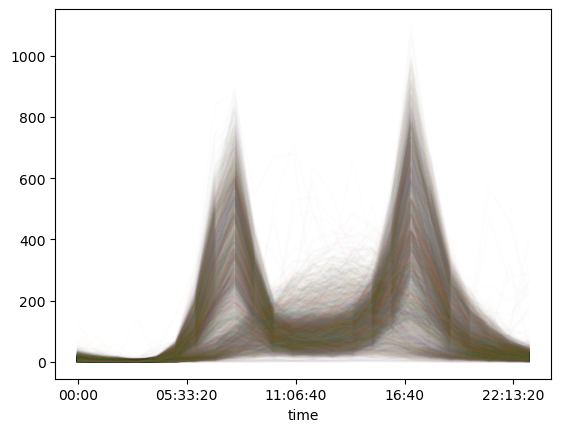

In [16]:
pivoted.plot(legend = False, alpha=0.01)